In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

https://www.kaggle.com/competitions/quora-question-pairs/data

In [2]:
df = pd.read_csv('quora-question-pairs/train.csv')
df.shape

(404290, 6)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [4]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
new_df = df.sample(20000, random_state=42)

In [7]:
print(df.memory_usage(deep=True).sum() / 1024**2)
print(new_df.memory_usage(deep=True).sum() / 1024**2)

103.20422458648682
5.252178192138672


In [8]:
del df

In [9]:
# print(df.memory_usage(deep=True).sum() / 1024**2)
print(new_df.memory_usage(deep=True).sum() / 1024**2)

5.252178192138672


In [10]:
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

is_duplicate
0    12606
1     7394
Name: count, dtype: int64
is_duplicate
0    63.03
1    36.97
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

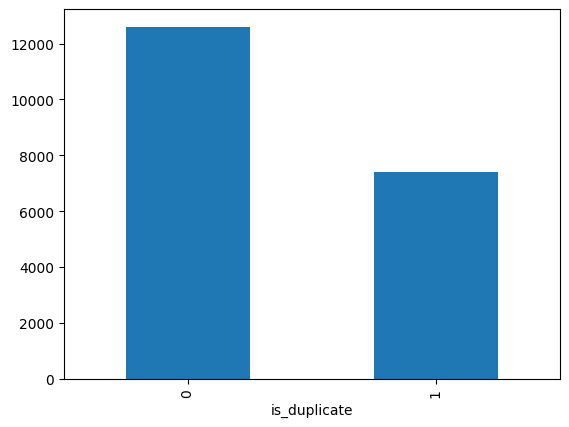

In [11]:
print(new_df.is_duplicate.value_counts())
print(new_df.is_duplicate.value_counts()/new_df.is_duplicate.count()*100)
new_df.is_duplicate.value_counts().plot(kind='bar')

In [12]:
allQuestionsIds = pd.Series(new_df.qid1.to_list() + new_df.qid2.tolist())
print(len(allQuestionsIds), type(allQuestionsIds))
print("Unique Questions: ", np.unique(allQuestionsIds).shape[0])
print("No. of questions that are repeated: ", (allQuestionsIds.value_counts() > 1).sum())

40000 <class 'pandas.core.series.Series'>
Unique Questions:  37753
No. of questions that are repeated:  1780


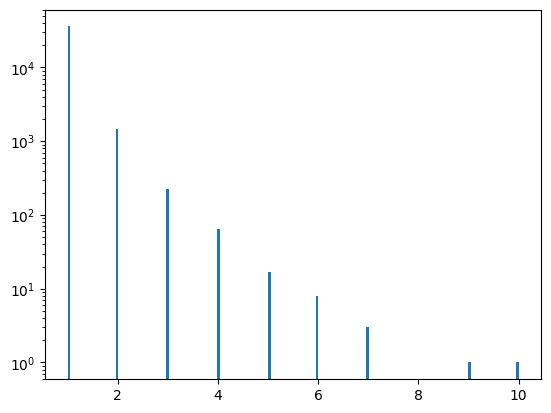

In [13]:
plt.hist(allQuestionsIds.value_counts().values, bins=160)
plt.yscale('log')
plt.show()

### Feature Engineering

In [14]:
new_df.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate'], dtype='object')

In [15]:
new_df['q1_len'] = new_df.question1.str.len()
new_df['q2_len'] = new_df.question2.str.len()

new_df['q1_num_words'] = new_df['question1'].str.split().str.len()
new_df['q2_num_words'] = new_df['question2'].str.split().str.len()

def common_words(row):
    w1 = set(row['question1'].lower().split())
    w2 = set(row['question2'].lower().split())
    return len(w1 & w2)

new_df['common_words_len'] = new_df.apply(common_words, axis=1)

def total_words(row):
    w1 = set(row['question1'].lower().split())
    w2 = set(row['question2'].lower().split())
    return len(w1 | w2)

new_df['total_words'] = new_df.apply(total_words, axis=1)

new_df['words_share'] = (new_df['common_words_len']/new_df['total_words']).fillna(0).round(2)

In [16]:
new_df.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate',
       'q1_len', 'q2_len', 'q1_num_words', 'q2_num_words', 'common_words_len',
       'total_words', 'words_share'],
      dtype='object')

Minimum Characters:  1
Maximum Characters:  334
Average Num of Characters:  59


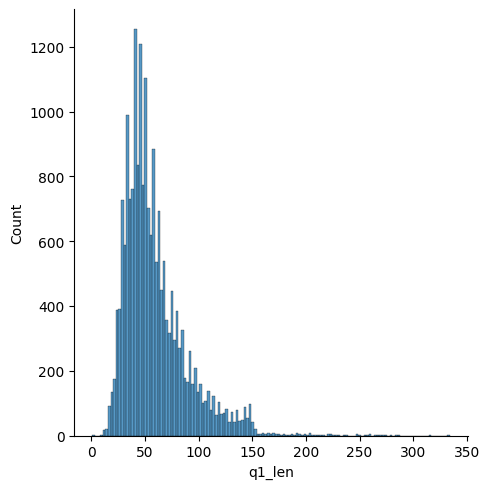

In [17]:
sns.displot(new_df.q1_len)
print('Minimum Characters: ', new_df.q1_len.min())
print('Maximum Characters: ', new_df.q1_len.max())
print('Average Num of Characters: ', int(new_df.q1_len.mean()))

Minimum Characters:  1
Maximum Characters:  1169
Average Num of Characters:  59


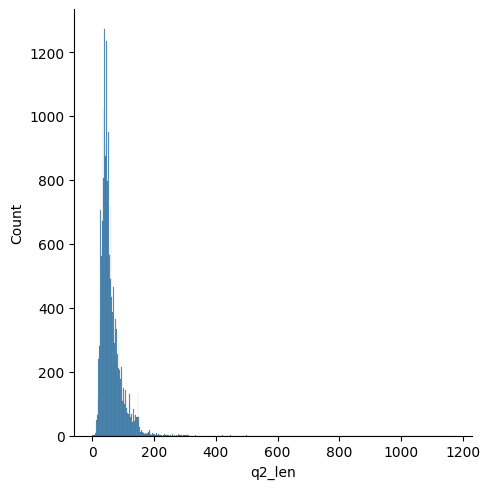

In [18]:
sns.displot(new_df.q2_len)
print('Minimum Characters: ', new_df.q2_len.min())
print('Maximum Characters: ', new_df.q2_len.max())
print('Average Num of Characters: ', int(new_df.q2_len.mean()))

Minimum Words:  1
Maximum Words:  67
Average Num of Words:  10


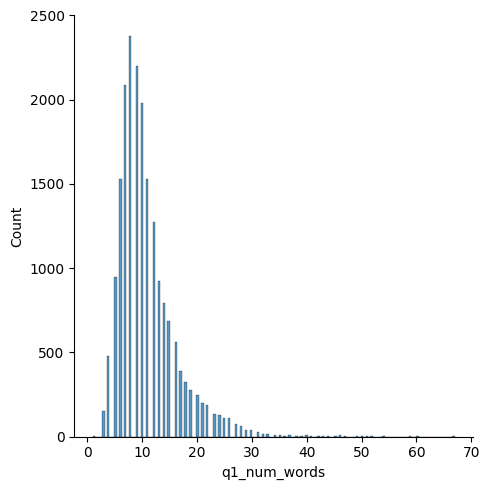

In [19]:
sns.displot(new_df.q1_num_words)
print('Minimum Words: ', new_df.q1_num_words.min())
print('Maximum Words: ', new_df.q1_num_words.max())
print('Average Num of Words: ', int(new_df.q1_num_words.mean()))

Minimum Words:  1
Maximum Words:  228
Average Num of Words:  11


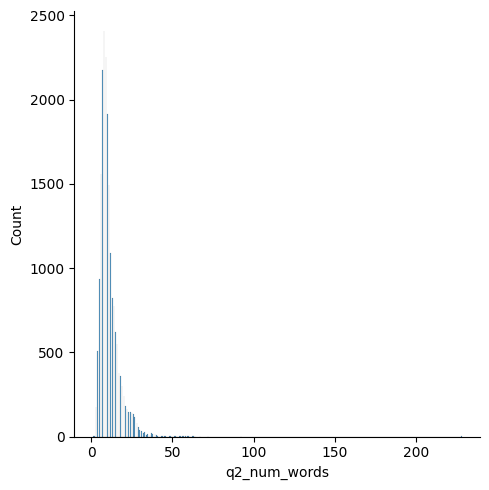

In [20]:
sns.displot(new_df.q2_num_words)
print('Minimum Words: ', new_df.q2_num_words.min())
print('Maximum Words: ', new_df.q2_num_words.max())
print('Average Num of Words: ', int(new_df.q2_num_words.mean()))

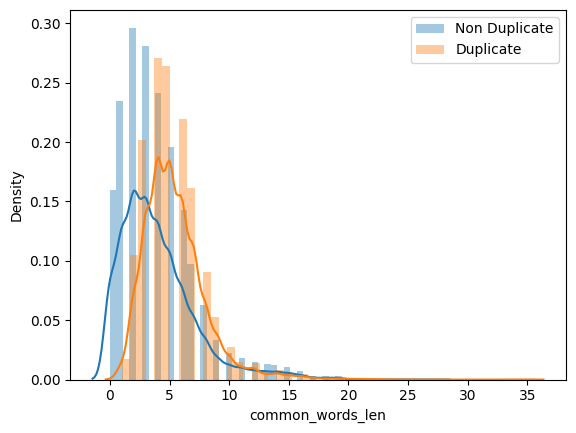

In [21]:
# Common Words
sns.distplot(new_df[new_df.is_duplicate == 0]['common_words_len'], label='Non Duplicate')
sns.distplot(new_df[new_df.is_duplicate == 1]['common_words_len'], label='Duplicate')
plt.legend()
plt.show()

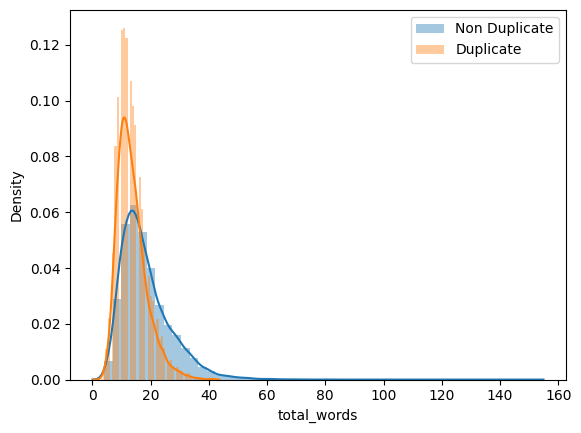

In [22]:
# Total Words
sns.distplot(new_df[new_df.is_duplicate == 0]['total_words'], label='Non Duplicate')
sns.distplot(new_df[new_df.is_duplicate == 1]['total_words'], label='Duplicate')
plt.legend()
plt.show()

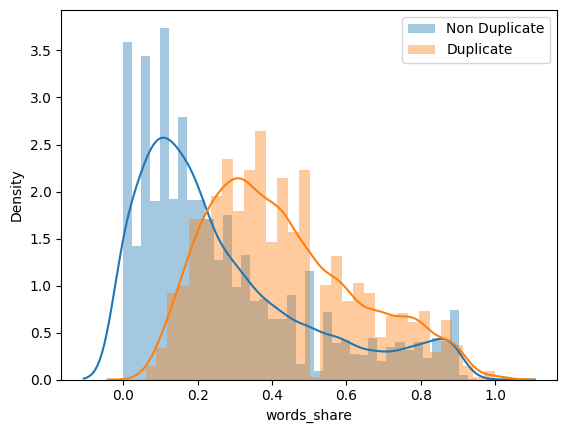

In [23]:
# Words Share
sns.distplot(new_df[new_df.is_duplicate == 0]['words_share'], label='Non Duplicate')
sns.distplot(new_df[new_df.is_duplicate == 1]['words_share'], label='Duplicate')
plt.legend()
plt.show()

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

questions = list(new_df.question1) + list(new_df.question2)
cv = CountVectorizer(max_features=2000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(), 2)

In [27]:
final_df = pd.DataFrame(np.concatenate([q1_arr, q2_arr], axis=1), index=new_df.index)

In [28]:
(final_df.isnull().sum() > 0).sum(), final_df.shape

(0, (20000, 4000))

In [29]:
final_df = pd.concat([final_df, new_df.drop(columns=['id', 'qid1', 'qid2', 'question1', 'question2'])], axis=1)

In [30]:
final_df.shape

(20000, 4008)

In [31]:
%whos

Variable          Type               Data/Info
----------------------------------------------
CountVectorizer   type               <class 'sklearn.feature_e<...>on.text.CountVectorizer'>
allQuestionsIds   Series             0         15738\n1       <...>ngth: 40000, dtype: int64
common_words      function           <function common_words at 0x7fa551713640>
cv                CountVectorizer    CountVectorizer(max_features=2000)
final_df          DataFrame                  0  1  2  3  4  5 <...>0000 rows x 4008 columns]
new_df            DataFrame                      id    qid1   <...>[20000 rows x 13 columns]
np                module             <module 'numpy' from '/ho<...>kages/numpy/__init__.py'>
pd                module             <module 'pandas' from '/h<...>ages/pandas/__init__.py'>
plt               module             <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
q1_arr            ndarray            20000x2000: 40000000 elems, type `int64`, 320000000 bytes (305.1757

In [32]:
del q1_arr, q2_arr
del questions
del new_df
del allQuestionsIds

In [41]:
final_df.columns = final_df.columns.astype(str)

In [42]:
X = final_df.drop(columns=['is_duplicate'])
y = final_df['is_duplicate']

In [43]:
final_df.head()

,0,1,2,3,4,5,6,7,8,9,...,3998,3999,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words_len,total_words,words_share
8067,0,0,0,0,0,0,0,0,0,0,...,0,0,0,34,34,8,8,7,9,0.78
368101,0,0,0,0,0,0,0,0,0,0,...,0,0,0,53,51,11,9,6,14,0.43
70497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,96,45,16,8,2,22,0.09
226567,0,0,0,0,0,0,0,0,0,0,...,0,0,1,44,52,7,9,4,12,0.33
73186,0,0,0,0,0,0,0,0,0,0,...,0,0,1,38,29,9,7,3,13,0.23


In [44]:
print(X.columns[:10])
print(X.columns[-10:])

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='object')
Index(['3997', '3998', '3999', 'q1_len', 'q2_len', 'q1_num_words',
       'q2_num_words', 'common_words_len', 'total_words', 'words_share'],
      dtype='object')


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred)

0.76725

In [47]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test, y_pred)

0.7595